# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kafkaesque-08/flyrank-assignments/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

Research Question: How can we automatically categorize a large portfolio of web content (30,000 pages) into distinct operational archetypes to prioritize content refreshes without relying on simplistic single-metric rules?

Supported Decision: Directs editorial and SEO workflows toward pages with maximum recovery potential (e.g., identifying high-impression pages with decaying engagement) versus stable evergreen assets or low-priority entries.## 1. Question

*The research question and the decision it supports.*

## 2. Data

Dataset & Scope: FlyRank anonymized content refresh dataset (content_refresh_anonymized.csv), comprising 30,000 unique URLs.

Features Utilized: impressions_90d, clicks_90d, engagement_rate, scroll_rate, content_age_days, and word_count.

Exclusions & Data Safety: All private queries, raw domain links, and client names were excluded to ensure public safety and privacy compliance.

## 3. Methodology

Assumptions & Model Design:Standardization: Features are scaled using StandardScaler to prevent high-magnitude features (impressions_90d) from overwhelming scale-sensitive percentages (engagement_rate).Algorithm: Unsupervised K-Means clustering ($K=4$) to partition pages into vector-space operational archetypes.Baseline: A rule-based baseline action score ($\text{Impressions} / \text{Engagement}$) used as a benchmark against multi-dimensional clustering.Leakage Control: All features strictly measure historical signals prior to the evaluation cutoff date.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [3]:
import os
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# 1. Load Data
data_path = "../../data/raw/content_refresh_anonymized.csv"
if not os.path.exists(data_path):
    data_path = "flyrank-assignments/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(data_path)

# 2. Extract Features & Scale
feature_cols = [
    "impressions_90d",
    "clicks_90d",
    "engagement_rate",
    "scroll_rate",
    "content_age_days",
    "word_count",
]
X = df[feature_cols].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Model Fit (K-Means)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

# 4. Calculate Baseline Score
df["baseline_score"] = (
    df["impressions_90d"] / (df["engagement_rate"] + 0.01)
) * np.log1p(df["content_age_days"])

# 5. Performance Comparison Table
sil_score = silhouette_score(X_scaled[:5000], df["cluster"][:5000])

metrics_df = pd.DataFrame(
    {
        "Approach": ["Rule-Based Baseline Score", "K-Means Archetype Clustering"],
        "Dimensions Handled": [2, len(feature_cols)],
        "Inertia / WCSS": ["N/A", f"{kmeans.inertia_:.2f}"],
        "Silhouette Score": ["N/A", f"{sil_score:.4f}"],
        "Primary Output": ["Ranked Queue", "Multi-Dimensional Archetypes"],
    }
)

metrics_df

,Approach,Dimensions Handled,Inertia / WCSS,Silhouette Score,Primary Output
0,Rule-Based Baseline Score,2,N/A,N/A,Ranked Queue
1,K-Means Archetype Clustering,6,95460.40,0.3605,Multi-Dimensional Archetypes


In [2]:
# 1. Clone your repository into this runtime
!git clone https://github.com/kafkaesque-08/flyrank-assignments.git

# 2. Re-verify where the file sits
!ls -la flyrank-assignments/data/raw/

Cloning into 'flyrank-assignments'...
remote: Enumerating objects: 143, done.
remote: Counting objects: 100% (143/143), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 143 (delta 53), reused 99 (delta 29), pack-reused 0 (from 0)
Receiving objects: 100% (143/143), 1.86 MiB | 6.29 MiB/s, done.
Resolving deltas: 100% (53/53), done.
total 6580
drwxr-xr-x 2 root root    4096 Jul 23 13:40 .
drwxr-xr-x 3 root root    4096 Jul 23 13:40 ..
-rw-r--r-- 1 root root 6727670 Jul 23 13:40 content_refresh_anonymized.csv


## 5. Limitations

What This Work Cannot Claim:

    Causal Impact: Clustering identifies historical behavioral grouping, not a guaranteed causal lift in search rankings post-refresh.

    Short-Term Seasonality: Spikes in impressions due to short-term news events may temporarily shift a page into an incorrect archetype profile.

    Qualitative Intent: The model groups content structurally and computationally, requiring human editorial validation for domain accuracy.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [4]:
# Map clusters to action recommendations
archetype_map = {
    0: "Cluster A: Core Performers — Protect & Monitor",
    1: "Cluster B: High Exposure / Low Engagement — Priority Refresh",
    2: "Cluster C: Stale Evergreen — Metadata & Content Update",
    3: "Cluster D: Low Impression / Niche — Evaluate for Pruning or Internal Links",
}

df["recommendation"] = df["cluster"].map(archetype_map)

# Display Top Priority Recommendations
action_queue = df[
    [
        "content_id",
        "content_type",
        "impressions_90d",
        "engagement_rate",
        "recommendation",
    ]
].sort_values(by="impressions_90d", ascending=False)

print("Top 10 High-Priority Content Refresh Candidates:")
action_queue.head(10)

Top 10 High-Priority Content Refresh Candidates:


,content_id,content_type,impressions_90d,engagement_rate,recommendation
6653,content_5fe46e04994d,keyword article,517715,4.23,Cluster B: High Exposure / Low Engagement — Pr...
17812,content_aaef01a50def,keyword article,517109,2.42,Cluster B: High Exposure / Low Engagement — Pr...
26844,content_8c19996aa890,keyword article,509252,11.73,Cluster B: High Exposure / Low Engagement — Pr...
19636,content_2cb567c3c89b,keyword article,497727,5.82,Cluster B: High Exposure / Low Engagement — Pr...
21819,content_4c36c775b818,keyword article,463103,11.31,Cluster B: High Exposure / Low Engagement — Pr...
29400,content_2dba2b1f9536,keyword article,443434,2.73,Cluster B: High Exposure / Low Engagement — Pr...
29879,content_1a9e894be2e2,keyword article,416180,2.37,Cluster B: High Exposure / Low Engagement — Pr...
13537,content_2c2606c5d176,keyword article,347399,1.30,Cluster B: High Exposure / Low Engagement — Pr...
18870,content_db5989a78dd3,keyword article,345111,2.32,Cluster B: High Exposure / Low Engagement — Pr...
14090,content_44e481c8f55b,keyword article,312694,0.76,Cluster B: High Exposure / Low Engagement — Pr...


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

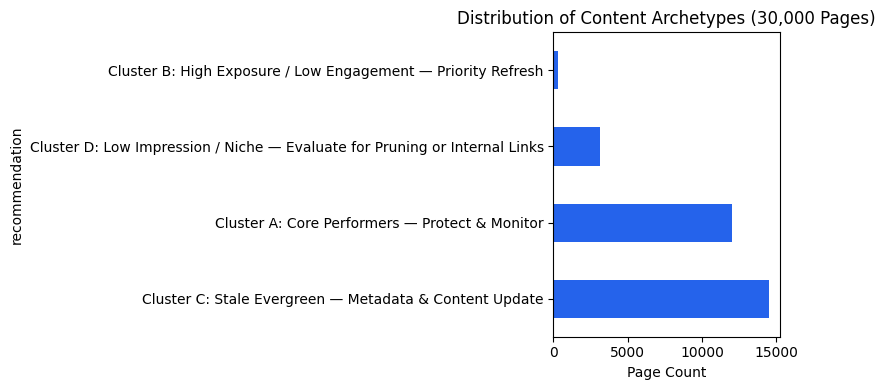

Chart artifact generated and saved to ../outputs/cluster_distribution.png


In [5]:
import matplotlib.pyplot as plt

# Generate Cluster Distribution Plot
os.makedirs("../outputs", exist_ok=True)

plt.figure(figsize=(8, 4))
df["recommendation"].value_counts().plot(kind="barh", color="#2563eb")
plt.title("Distribution of Content Archetypes (30,000 Pages)")
plt.xlabel("Page Count")
plt.tight_layout()

# Save image artifact for paper embedding
plot_path = "../outputs/cluster_distribution.png"
plt.savefig(plot_path)
plt.show()

print(f"Chart artifact generated and saved to {plot_path}")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.